In [1]:

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline 
import seaborn as sns
sns.set_style('darkgrid')

In [2]:
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


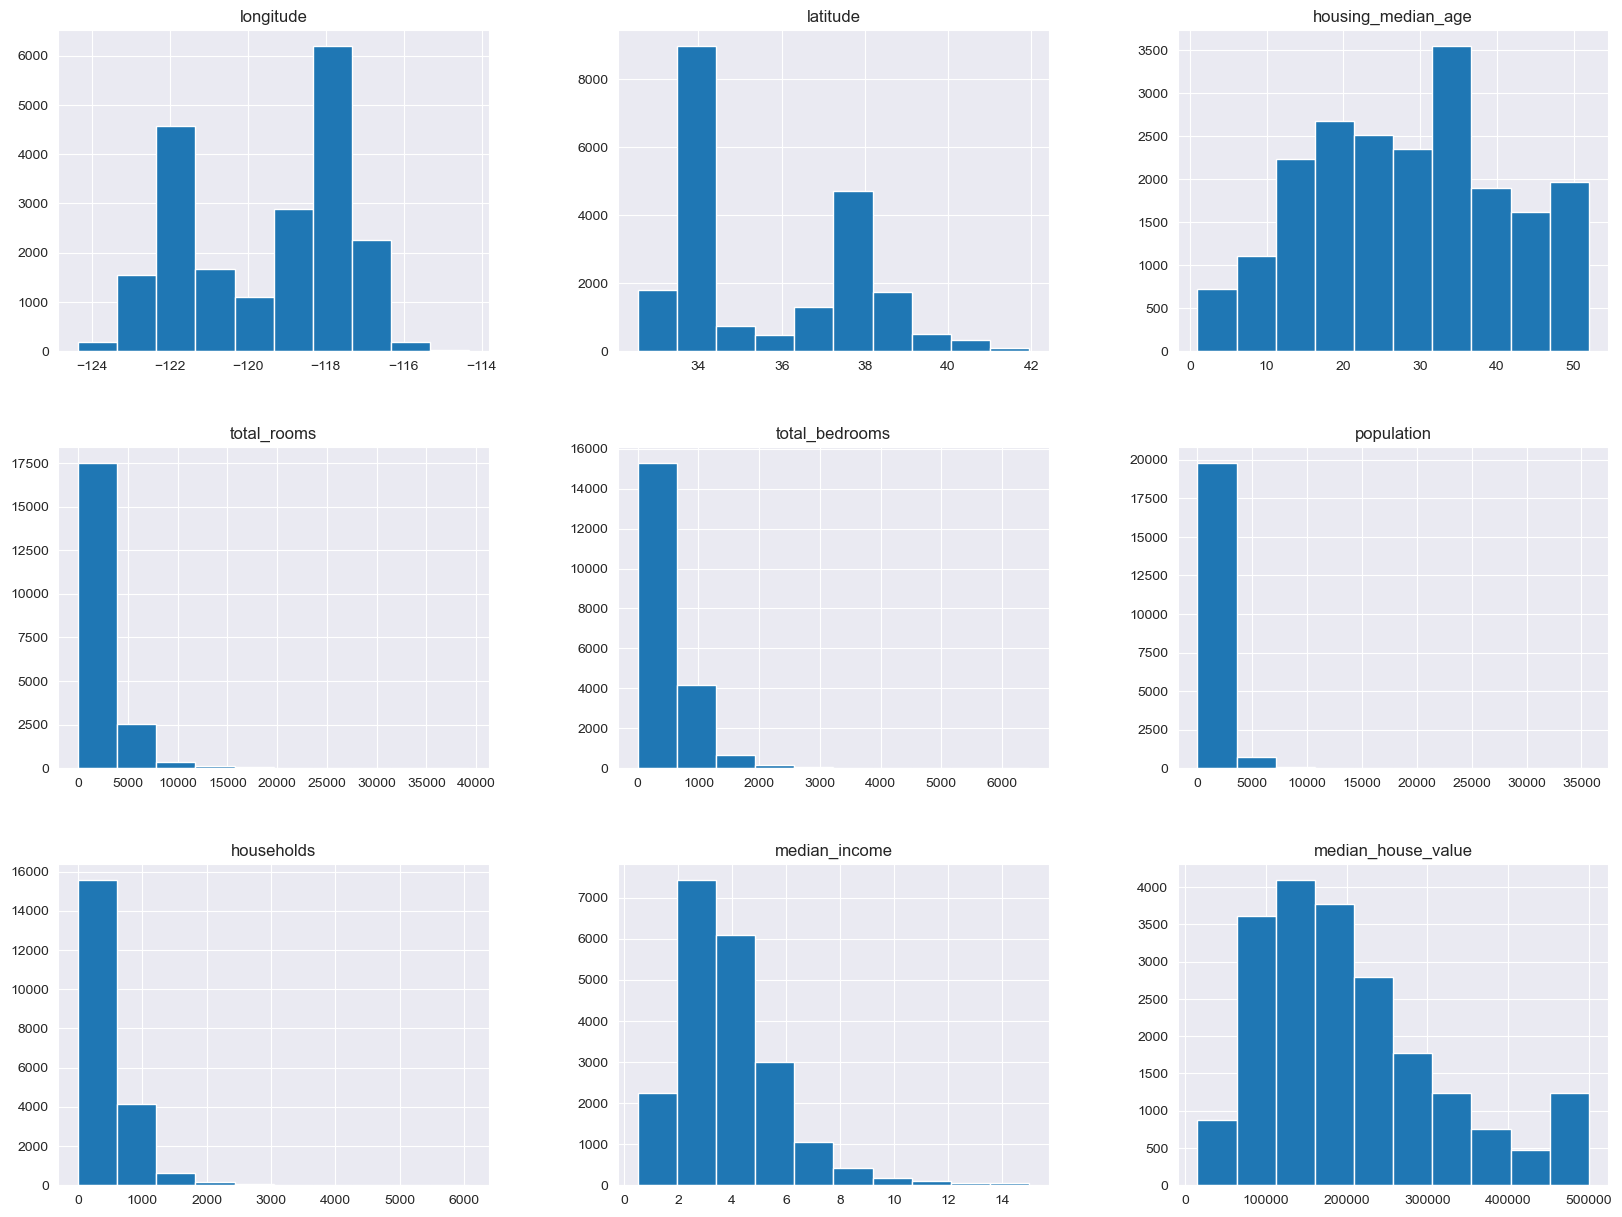

In [6]:
df.hist(figsize=(20, 15))
# plt.figure(figsize=[80, 80])
plt.show();

In [7]:
df["income_cat"]= np.ceil(df["median_income"]/1.5)
df["income_cat"].where(df["income_cat"] < 5, 5.0, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_9680\336706143.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["income_cat"].where(df["income_cat"] < 5, 5.0, inplace=True)


In [8]:
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data)* test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices =shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [9]:
train_indices, test_indices = split_train_test(df, 0.2)
len(train_indices)


16512

In [10]:
len(test_indices)

4128

In [11]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

In [12]:
len(train_set)


16512

In [13]:
len(test_set)

4128

In [14]:
df["income_cat"]= np.ceil(df["median_income"]/1.5)
df["income_cat"].where(df["income_cat"] < 5, 5.0, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_9680\336706143.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["income_cat"].where(df["income_cat"] < 5, 5.0, inplace=True)


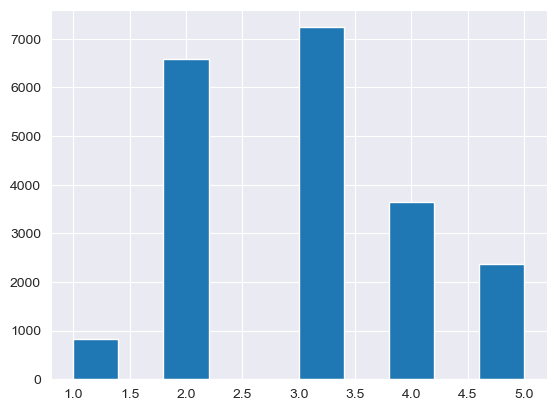

In [15]:
df['income_cat'].hist()
plt.show()

In [16]:
from sklearn.model_selection import StratifiedShuffleSplit 
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

In [17]:
for train_index, test_index in split.split(df, df['income_cat']):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

In [18]:
strat_test_set['income_cat'].value_counts()/len(strat_test_set)

income_cat
3.0    0.350533
2.0    0.318798
4.0    0.176357
5.0    0.114341
1.0    0.039971
Name: count, dtype: float64

In [19]:
train_indices

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
15989,-122.47,37.76,39.0,3200.0,689.0,1391.0,618.0,3.6346,338000.0,NEAR BAY,3.0
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,140400.0,<1H OCEAN,3.0
20571,-121.99,38.53,6.0,4598.0,834.0,2561.0,812.0,3.4186,127300.0,INLAND,3.0
9775,-121.24,36.33,13.0,1642.0,418.0,1534.0,388.0,3.1222,125500.0,<1H OCEAN,3.0
16634,-120.84,35.31,23.0,3100.0,603.0,1515.0,609.0,2.8493,196100.0,NEAR OCEAN,2.0
...,...,...,...,...,...,...,...,...,...,...,...
14980,-117.01,32.71,20.0,3506.0,692.0,1977.0,668.0,2.9810,129100.0,NEAR OCEAN,2.0
13879,-117.38,34.44,4.0,5083.0,867.0,2541.0,856.0,4.2414,121400.0,INLAND,3.0
10071,-120.17,39.32,14.0,2421.0,489.0,1000.0,354.0,3.5652,119800.0,INLAND,3.0
4374,-118.28,34.10,49.0,1767.0,467.0,1066.0,438.0,3.0958,210900.0,<1H OCEAN,3.0


In [20]:
df2 = pd.DataFrame(data = {
    'train_indicator' : train_indices['income_cat'],
    'train_set' : train_set['income_cat'],
    'strat_train_set' : strat_train_set['income_cat'],

})
df2.head()

,train_indicator,train_set,strat_train_set
0,5.0,NaN,5.0
1,5.0,5.0,5.0
2,NaN,5.0,5.0
3,NaN,NaN,4.0
4,3.0,3.0,3.0


In [21]:
df.income_cat.mean()

np.float64(3.006686046511628)

In [22]:
df2.describe()

,train_indicator,train_set,strat_train_set
count,16512.000000,16512.000000,16512.000000
mean,3.009993,3.012960,3.006783
std,1.056612,1.057124,1.054600
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000
50%,3.000000,3.000000,3.000000
75%,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000


In [23]:
housing = strat_train_set.copy()

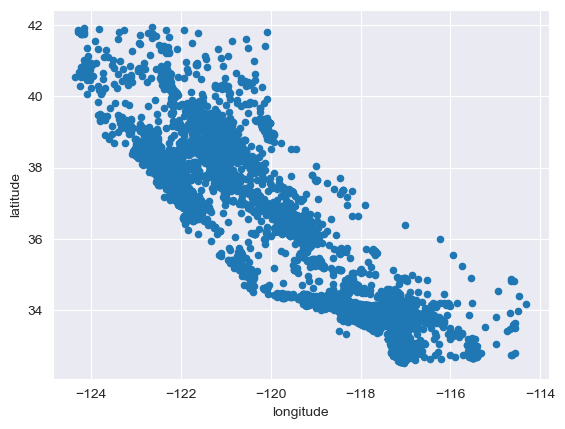

In [24]:
housing.plot(kind='scatter', x='longitude', y='latitude')
plt.show()

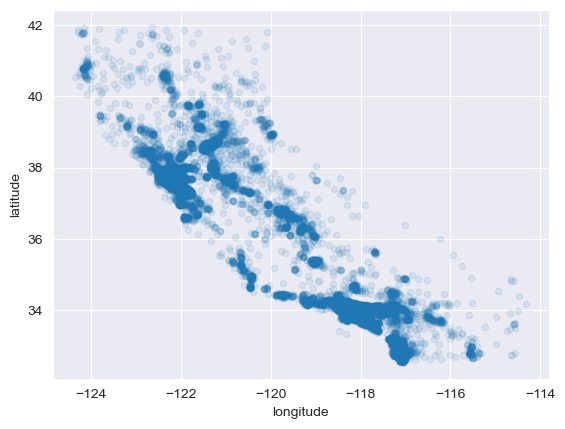

In [25]:
housing.plot(kind='scatter', x='longitude', y='latitude' ,alpha=0.1
            )
plt.show()

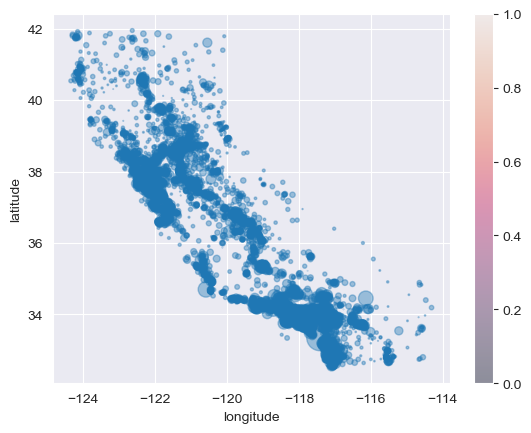

In [26]:
housing.plot(kind='scatter', x='longitude', y='latitude' ,alpha=0.4, s=housing['population']/100, colorbar=True)
plt.show()

In [27]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16354 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
 10  income_cat          16512 non-null  float64
dtypes: float64(10), object(1)
memory usage: 2.0+ MB


In [28]:
housing_two = housing.iloc[:, np.r_[0:9, 10]]
housing_two.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16354 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   income_cat          16512 non-null  float64
dtypes: float64(10)
memory usage: 1.9 MB


In [29]:
corr_matric = housing_two.corr()

In [30]:
corr_matric = housing_two.corr()
corr_matric["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
income_cat            0.642256
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

In [31]:
from pandas.plotting import scatter_matrix

In [32]:
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]

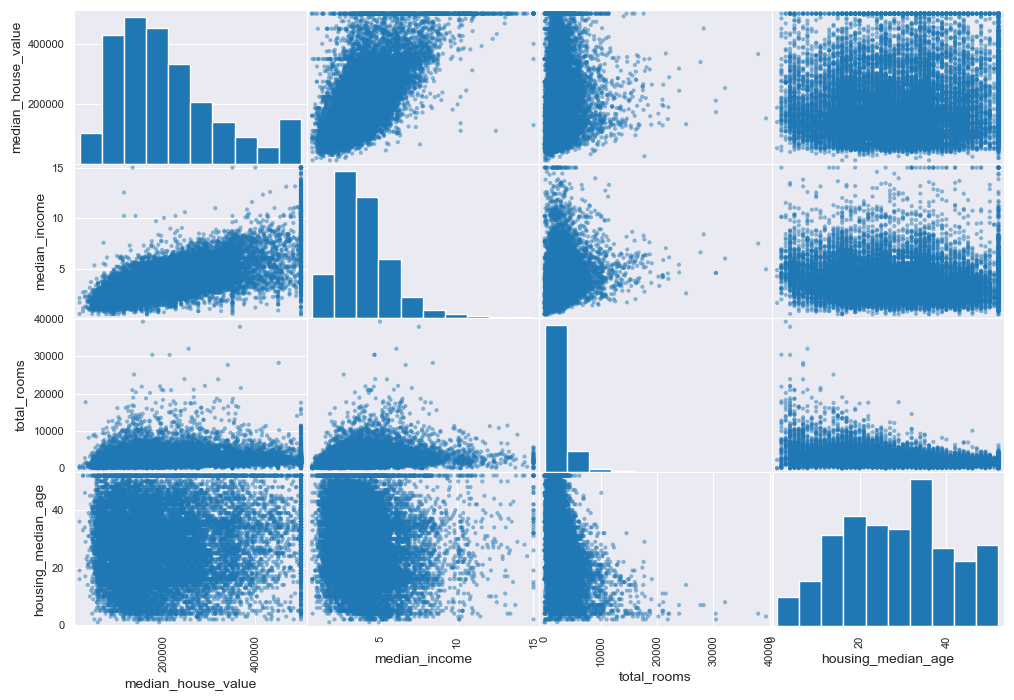

In [33]:
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

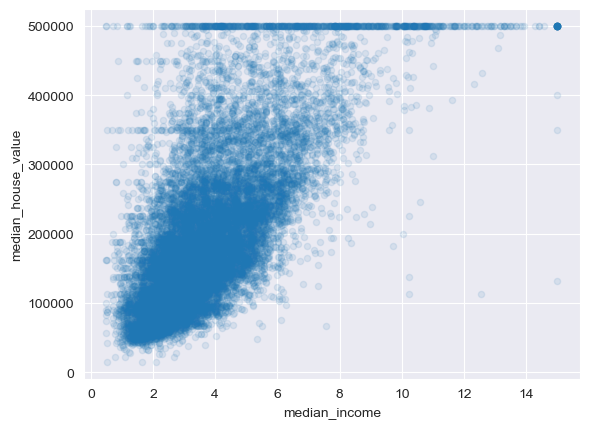

In [34]:
housing_two.plot(kind='scatter', x='median_income', y='median_house_value', alpha=0.1)
plt.show()

In [35]:
housing["room_per_household"]=housing['total_rooms']/housing['households']
housing["bedroom_per_household"]=housing['total_bedrooms']/housing['total_rooms']
housing["population_per_household"]=housing['population']/housing['households']


In [36]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 16512 non-null  float64
 1   latitude                  16512 non-null  float64
 2   housing_median_age        16512 non-null  float64
 3   total_rooms               16512 non-null  float64
 4   total_bedrooms            16354 non-null  float64
 5   population                16512 non-null  float64
 6   households                16512 non-null  float64
 7   median_income             16512 non-null  float64
 8   median_house_value        16512 non-null  float64
 9   ocean_proximity           16512 non-null  object 
 10  income_cat                16512 non-null  float64
 11  room_per_household        16512 non-null  float64
 12  bedroom_per_household     16354 non-null  float64
 13  population_per_household  16512 non-null  float64
dtypes: floa

In [37]:
housing_three = housing.iloc[:, np.r_[0:9, 10:13]]
housing_three.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   longitude              16512 non-null  float64
 1   latitude               16512 non-null  float64
 2   housing_median_age     16512 non-null  float64
 3   total_rooms            16512 non-null  float64
 4   total_bedrooms         16354 non-null  float64
 5   population             16512 non-null  float64
 6   households             16512 non-null  float64
 7   median_income          16512 non-null  float64
 8   median_house_value     16512 non-null  float64
 9   income_cat             16512 non-null  float64
 10  room_per_household     16512 non-null  float64
 11  bedroom_per_household  16354 non-null  float64
dtypes: float64(12)
memory usage: 2.1 MB


In [38]:
corr_matric = housing_three.corr()
corr_matric["median_house_value"].sort_values(ascending=False)

median_house_value       1.000000
median_income            0.687151
income_cat               0.642256
room_per_household       0.146255
total_rooms              0.135140
housing_median_age       0.114146
households               0.064590
total_bedrooms           0.047781
population              -0.026882
longitude               -0.047466
latitude                -0.142673
bedroom_per_household   -0.259952
Name: median_house_value, dtype: float64

In [39]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [40]:
sum(housing.total_bedrooms.isnull())


158

In [41]:
sum(strat_train_set.total_bedrooms.isnull())

158

In [42]:
median = housing["total_bedrooms"].median()
housing["total_bedrooms"].fillna(median, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_9680\2694038511.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing["total_bedrooms"].fillna(median, inplace=True)


In [43]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  object 
 9   income_cat          16512 non-null  float64
dtypes: float64(9), object(1)
memory usage: 1.9+ MB


In [44]:
from sklearn.impute import SimpleImputer
impute = SimpleImputer(strategy="median")


In [45]:
housing_num = housing.drop("ocean_proximity", axis=1)

In [46]:
impute.fit(housing_num)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [47]:
impute.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155,    3.     ])

In [48]:
housing_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155,    3.     ])

In [49]:
X = impute.transform(housing_num)

In [50]:
X

array([[-121.46  ,   38.52  ,   29.    , ...,  706.    ,    2.1736,
           2.    ],
       [-117.23  ,   33.09  ,    7.    , ...,  768.    ,    6.3373,
           5.    ],
       [-119.04  ,   35.37  ,   44.    , ...,  300.    ,    2.875 ,
           2.    ],
       ...,
       [-122.72  ,   38.44  ,   48.    , ...,  172.    ,    3.1797,
           3.    ],
       [-122.7   ,   38.31  ,   14.    , ...,  501.    ,    4.1964,
           3.    ],
       [-122.14  ,   39.97  ,   27.    , ...,  197.    ,    3.1319,
           3.    ]], shape=(16512, 9))

In [51]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns)

In [52]:
housing_tr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   income_cat          16512 non-null  float64
dtypes: float64(9)
memory usage: 1.1 MB


In [53]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     7277
INLAND        5262
NEAR OCEAN    2124
NEAR BAY      1847
ISLAND           2
Name: count, dtype: int64

In [54]:
housing_cat = housing[['ocean_proximity']]


In [55]:
housing_cat

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
...,...
15174,<1H OCEAN
12661,INLAND
19263,<1H OCEAN
19140,<1H OCEAN


In [56]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()

In [57]:
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)


In [58]:
housing_cat_encoded[:10]

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [59]:
from sklearn.preprocessing import OneHotEncoder

In [60]:
cat_encoder = OneHotEncoder()

In [61]:
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [62]:
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [63]:
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(16512, 5))

In [64]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [65]:
class human:
    def __init__(self, eyes, nose):
        self.eyes=eyes
        self.nose=nose
    def getter(self):
        return {
            'eyes' : self.eyes,
            'nose' : self.nose
        }
class man(human):
    pass;
    

In [66]:
adam = man('white', 'black')
adam.getter()

{'eyes': 'white', 'nose': 'black'}

In [67]:
from sklearn.base import BaseEstimator , TransformerMixin

In [68]:
rooms_ix, bedrooms_ix, population_ix, households_ix = 3,4,5,6

In [69]:
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] /  X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]


In [70]:
attribs_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attisbs = attribs_adder.transform(housing.values)

In [71]:
housing_extra_attisbs

array([[-121.46, 38.52, 29.0, ..., 2.0, 5.485835694050992,
        3.168555240793201],
       [-117.23, 33.09, 7.0, ..., 5.0, 6.927083333333333,
        2.6236979166666665],
       [-119.04, 35.37, 44.0, ..., 2.0, 5.3933333333333335,
        2.223333333333333],
       ...,
       [-122.72, 38.44, 48.0, ..., 3.0, 4.1104651162790695,
        2.6627906976744184],
       [-122.7, 38.31, 14.0, ..., 3.0, 6.297405189620759,
        2.411177644710579],
       [-122.14, 39.97, 27.0, ..., 3.0, 5.477157360406092,
        3.1725888324873095]], shape=(16512, 12), dtype=object)

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy="median")),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler()),
    
])


In [73]:
housing_num_tr = num_pipeline.fit_transform(housing_num)

In [74]:
from sklearn.compose import ColumnTransformer

num_attribs = list(housing_num)
num_attribs

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'income_cat']

In [75]:
cat_attribs = ["ocean_proximity"]
cat_attribs

['ocean_proximity']

In [76]:
full_pipeline= ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

In [77]:
housing_prepared = full_pipeline.fit_transform(housing)

In [78]:
housing_prepared


array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.        ,
         0.        ,  0.        ],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.        ,
         0.        ,  0.        ]], shape=(16512, 17))

In [79]:
housing_prepared

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.        ,
         0.        ,  0.        ],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.        ,
         0.        ,  0.        ]], shape=(16512, 17))

In [80]:
housing_labels

12655     72100.0
15502    279600.0
2908      82700.0
14053    112500.0
20496    238300.0
           ...   
15174    268500.0
12661     90400.0
19263    140400.0
19140    258100.0
19773     62700.0
Name: median_house_value, Length: 16512, dtype: float64

In [81]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [83]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]


In [84]:
some_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND,2.0
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN,5.0
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND,2.0
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN,2.0
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN,3.0


In [85]:
some_labels

12655     72100.0
15502    279600.0
2908      82700.0
14053    112500.0
20496    238300.0
Name: median_house_value, dtype: float64

In [86]:
some_data_prepared = full_pipeline.transform(some_data)

In [87]:
print("predictions", lin_reg.predict(some_data_prepared))

predictions [ 83811.08312039 314388.27147935 145641.85902864 183704.64921202
 238729.66725745]


In [88]:
print("Labels", list(some_labels))

Labels [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [89]:
from sklearn.metrics import mean_squared_error
housing_prediction = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_prediction)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(68376.51254853733)

In [90]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [91]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

np.float64(0.0)

In [92]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [93]:
tree_rmse_scores

array([72005.52739188, 70802.04054742, 67457.84476812, 72576.17578367,
       69622.02113159, 76053.59569795, 72997.6824789 , 74020.76875165,
       67521.11298436, 70562.75594551])

In [94]:
print(tree_rmse_scores)

[72005.52739188 70802.04054742 67457.84476812 72576.17578367
 69622.02113159 76053.59569795 72997.6824789  74020.76875165
 67521.11298436 70562.75594551]


In [95]:
def display_scores(scores):
    print("Scores:" , scores )
    print("Mean:", scores.mean())
    print("Standard deviation: ", scores.std())

In [96]:
display_scores(tree_rmse_scores)

Scores: [72005.52739188 70802.04054742 67457.84476812 72576.17578367
 69622.02113159 76053.59569795 72997.6824789  74020.76875165
 67521.11298436 70562.75594551]
Mean: 71361.9525481053
Standard deviation:  2600.358479247817


In [97]:
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [71523.78333874 64044.46774989 67454.97869698 68514.10137273
 66303.62531226 72166.63405138 74464.08841381 68570.11804395
 66063.64175868 69870.86192291]
Mean: 68897.63006613277
Standard deviation:  3002.746127534861


In [98]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [99]:
housing_labels.shape , housing_prepared.shape

((16512,), (16512, 17))

In [100]:
forest_reg_predict = forest_reg.predict(housing_prepared)
forest_reg_mse = mean_squared_error(housing_labels, forest_reg_predict)
forest_reg_rmse = np.sqrt(forest_reg_mse)
forest_reg_rmse

np.float64(18669.21547916064)

In [101]:
forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,  scoring="neg_mean_squared_error", cv=10)


In [102]:
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores: [51447.51951109 49012.468938   46326.48875308 52327.60530062
 47349.85715761 51842.31714118 52795.79711271 49562.96151951
 48605.99197696 53571.4924124 ]
Mean: 50284.249982315116
Standard deviation:  2330.207527419843


In [103]:
import joblib

In [104]:
joblib.dump(forest_scores, "sam.pkl" )

['sam.pkl']

In [105]:
forest_scored = joblib.load("sam.pkl")

In [106]:
forest_rmse_scores = np.sqrt(-forest_scored)
display_scores(forest_rmse_scores)

Scores: [51447.51951109 49012.468938   46326.48875308 52327.60530062
 47349.85715761 51842.31714118 52795.79711271 49562.96151951
 48605.99197696 53571.4924124 ]
Mean: 50284.249982315116
Standard deviation:  2330.207527419843


In [111]:
from sklearn.model_selection import GridSearchCV
param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features':[2,4,6,8]},
    {'bootstrap': [False], 'n_estimators': [3,10], 'max_features': [2, 3, 4]},
]
forest_reg = RandomForestRegressor()
grid_search = GridSearchCV(
    forest_reg, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True
)
grid_search.fit(housing_prepared, housing_labels)

,estimator,RandomForestRegressor()
,param_grid,"[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,30


In [115]:
grid_search.best_params_

{'max_features': 6, 'n_estimators': 30}

In [114]:
grid_search.best_estimator_

,n_estimators,30
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,6
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [119]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

64564.18652306663 {'max_features': 2, 'n_estimators': 3}
55659.65856111626 {'max_features': 2, 'n_estimators': 10}
53200.72665290902 {'max_features': 2, 'n_estimators': 30}
60569.14770198918 {'max_features': 4, 'n_estimators': 3}
53836.656246220715 {'max_features': 4, 'n_estimators': 10}
51306.4780310175 {'max_features': 4, 'n_estimators': 30}
60712.29410044689 {'max_features': 6, 'n_estimators': 3}
52973.16709093116 {'max_features': 6, 'n_estimators': 10}
50570.67384104361 {'max_features': 6, 'n_estimators': 30}
59274.37367810277 {'max_features': 8, 'n_estimators': 3}
52817.82779399083 {'max_features': 8, 'n_estimators': 10}
50636.658096024046 {'max_features': 8, 'n_estimators': 30}
62698.25041319381 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
54809.44052620719 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
60697.342811913295 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
53005.90496727166 {'bootstrap': False, 'max_features': 3, 'n_estimators': 